In [13]:
import os
import subprocess
import sys

import numpy as np

import matplotlib.pyplot as plt

from openfast_toolbox.io import FASTOutputFile
from openfast_toolbox.postpro import equivalent_load

# Add the directory containing utils.py to the Python path
utils_path = "/Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/Utils"
sys.path.append(utils_path)

# Now you can import the functions from utils.py
from utils import run_openfast, read_openfast_output, read_weis_output, readline_filterComments
from compute_damage_equivalent_load import compute_damage_equivalent_load

In [14]:
folder = "/Users/li/Desktop/Wind/WEIS/examples/06_IEA-15-240-RWT/outputs/06_IEA15_single_run/openfast_runs"
file_name0 = "DLC1.1_0_weis_job_0.outb"
# file_name1 = "weis_job_1.outb"
# file_name2 = "weis_job_2.outb"
# file_name3 = "weis_job_3.outb"

In [15]:
df0 = read_weis_output(folder, file_name0)
# df1 = read_weis_output(folder, file_name1)
# df2 = read_weis_output(folder, file_name2)
# df3 = read_weis_output(folder, file_name3)

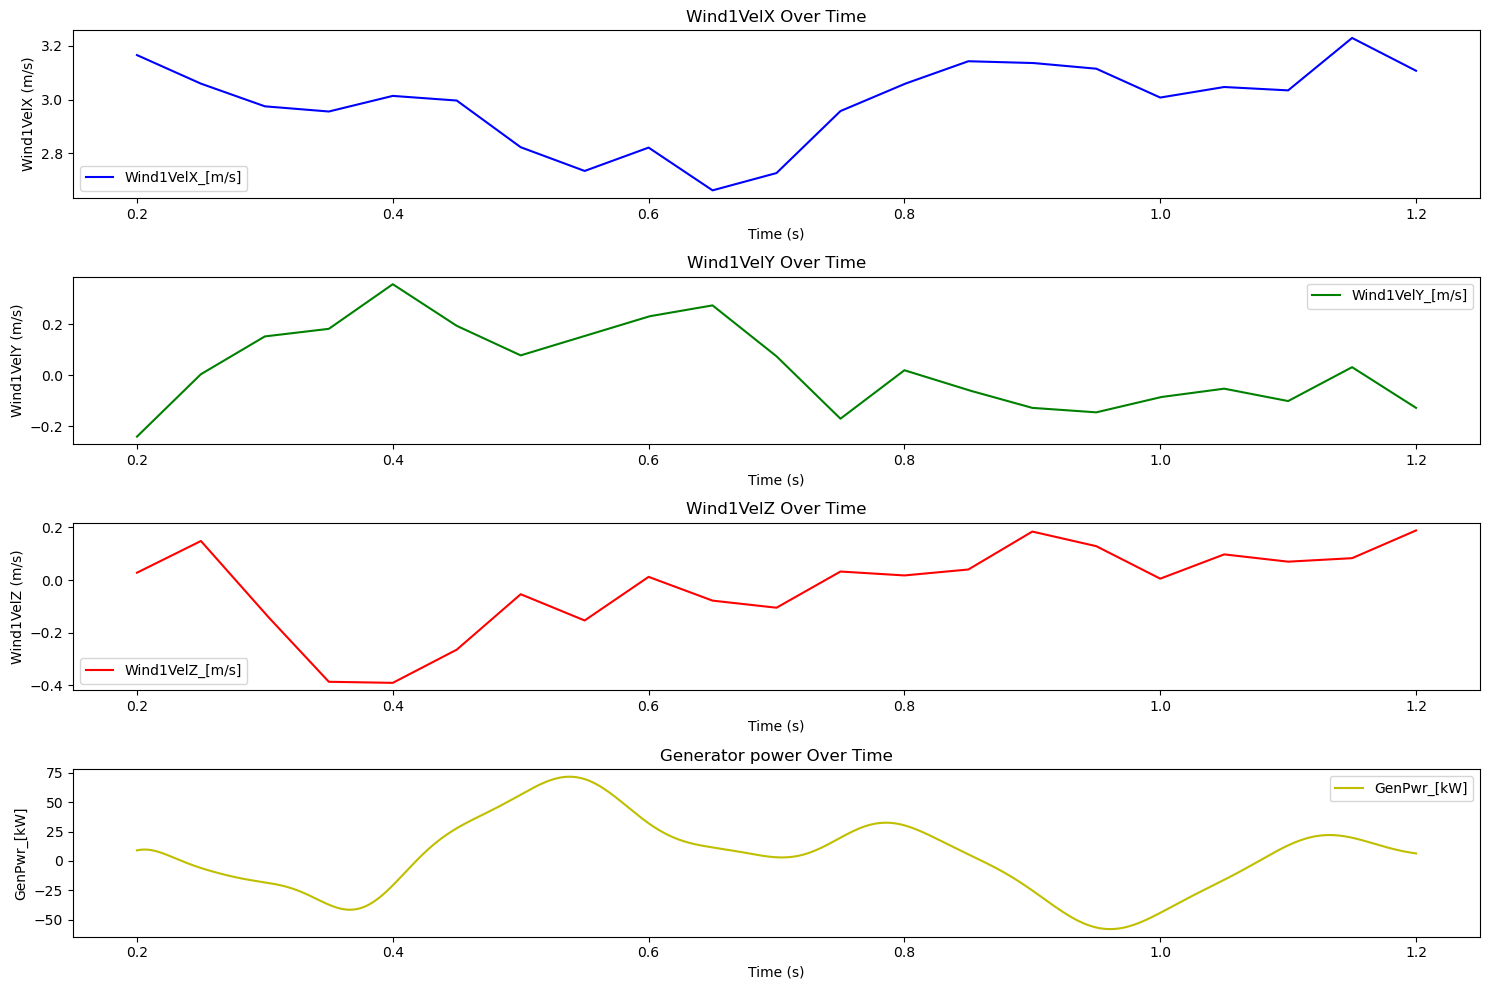

In [16]:
# Create the plots
plt.figure(figsize=(15, 10))

# Plot Wind1VelX_[m/s] over Time_[s]
plt.subplot(4, 1, 1)
plt.plot(df0['Time_[s]'], df0['Wind1VelX_[m/s]'], label='Wind1VelX_[m/s]', color='b')
plt.xlabel('Time (s)')
plt.ylabel('Wind1VelX (m/s)')
plt.title('Wind1VelX Over Time')
plt.legend()

# Plot Wind1VelY_[m/s] over Time_[s]
plt.subplot(4, 1, 2)
plt.plot(df0['Time_[s]'], df0['Wind1VelY_[m/s]'], label='Wind1VelY_[m/s]', color='g')
plt.xlabel('Time (s)')
plt.ylabel('Wind1VelY (m/s)')
plt.title('Wind1VelY Over Time')
plt.legend()

# Plot Wind1VelZ_[m/s] over Time_[s]
plt.subplot(4, 1, 3)
plt.plot(df0['Time_[s]'], df0['Wind1VelZ_[m/s]'], label='Wind1VelZ_[m/s]', color='r')
plt.xlabel('Time (s)')
plt.ylabel('Wind1VelZ (m/s)')
plt.title('Wind1VelZ Over Time')
plt.legend()

# Plot Wind1VelZ_[m/s] over Time_[s]
plt.subplot(4, 1, 4)
plt.plot(df0['Time_[s]'], df0['GenPwr_[kW]'], label='GenPwr_[kW]', color='y')
plt.xlabel('Time (s)')
plt.ylabel('GenPwr_[kW]')
plt.title('Generator power Over Time')
plt.legend()
# Adjust layout and show the plots
plt.tight_layout()
plt.show()

In [17]:
# Display all columns with proper formatting and scrolling
import pandas as pd

# Set pandas options for better display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print(f"Total number of columns: {len(df0.columns)}")
print("\nAll available columns:")
print("="*80)

# Display columns in a more readable format
for i, col in enumerate(df0.columns, 1):
    print(f"{i:3d}. {col}")

print("="*80)
print(f"DataFrame shape: {df0.shape}")
print(f"Time range: {df0['Time_[s]'].min():.3f} to {df0['Time_[s]'].max():.3f} seconds")

Total number of columns: 337

All available columns:
  1. Time_[s]
  2. Wind1VelX_[m/s]
  3. Wind1VelY_[m/s]
  4. Wind1VelZ_[m/s]
  5. Azimuth_[deg]
  6. BldPitch1_[deg]
  7. BldPitch2_[deg]
  8. BldPitch3_[deg]
  9. GenSpeed_[rpm]
 10. LSSTipMya_[kN-m]
 11. LSSTipMys_[kN-m]
 12. LSSTipMza_[kN-m]
 13. LSSTipMzs_[kN-m]
 14. LSShftFxa_[kN]
 15. LSShftFxs_[kN]
 16. LSShftFya_[kN]
 17. LSShftFys_[kN]
 18. LSShftFza_[kN]
 19. LSShftFzs_[kN]
 20. NacYaw_[deg]
 21. NcIMURAys_[deg/s^2]
 22. NcIMUTAxs_[m/s^2]
 23. NcIMUTAzs_[m/s^2]
 24. PtfmHeave_[m]
 25. PtfmPitch_[deg]
 26. PtfmRoll_[deg]
 27. PtfmSurge_[m]
 28. PtfmSway_[m]
 29. PtfmYaw_[deg]
 30. RootFxb1_[NVALI]
 31. RootFxb2_[NVALI]
 32. RootFxb3_[NVALI]
 33. RootFxc1_[NVALI]
 34. RootFxc2_[NVALI]
 35. RootFxc3_[NVALI]
 36. RootFyb1_[NVALI]
 37. RootFyb2_[NVALI]
 38. RootFyb3_[NVALI]
 39. RootFyc1_[NVALI]
 40. RootFyc2_[NVALI]
 41. RootFyc3_[NVALI]
 42. RootFzb1_[NVALI]
 43. RootFzb2_[NVALI]
 44. RootFzb3_[NVALI]
 45. RootFzc1_[NVALI]
 46